# 525 Bird Species — Dataset Exploration

This notebook explores the **525 Bird Species Image Classification** dataset, available on HuggingFace:
- **Dataset page:** [huggingface.co/datasets/yashikota/birds-525-species-image-classification](https://huggingface.co/datasets/yashikota/birds-525-species-image-classification)
- **Access:** Loaded via the HuggingFace `datasets` library, cached locally to `data/raw/`.

In [2]:
from datasets import load_dataset
from pathlib import Path

RAW_DATA_DIR = Path("../data/raw/birds-525")

dataset = load_dataset("parquet", data_dir=str(RAW_DATA_DIR / "data"))

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 84635
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2625
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2625
    })
})


## 1. Class Information

In [3]:
label_names = dataset["train"].features["label"].names
num_classes = len(label_names)

print(f"Number of classes: {num_classes}")
print(f"\nFirst 10 classes: {label_names[:10]}")
print(f"Last 10 classes:  {label_names[-10:]}")

Number of classes: 526

First 10 classes: ['ABBOTTS BABBLER', 'ABBOTTS BOOBY', 'ABYSSINIAN GROUND HORNBILL', 'AFRICAN CROWNED CRANE', 'AFRICAN EMERALD CUCKOO', 'AFRICAN FIREFINCH', 'AFRICAN OYSTER CATCHER', 'AFRICAN PIED HORNBILL', 'AFRICAN PYGMY GOOSE', 'ALBATROSS']
Last 10 classes:  ['WILSONS BIRD OF PARADISE', 'WOOD DUCK', 'WOOD THRUSH', 'WOODLAND KINGFISHER', 'WRENTIT', 'YELLOW BELLIED FLOWERPECKER', 'YELLOW BREASTED CHAT', 'YELLOW CACIQUE', 'YELLOW HEADED BLACKBIRD', 'ZEBRA DOVE']


## 2. Class Distribution

Min images per class: 130 (AMETHYST WOODSTAR)
Max images per class: 263 (RUFOUS TREPE)
Mean images per class: 161.2


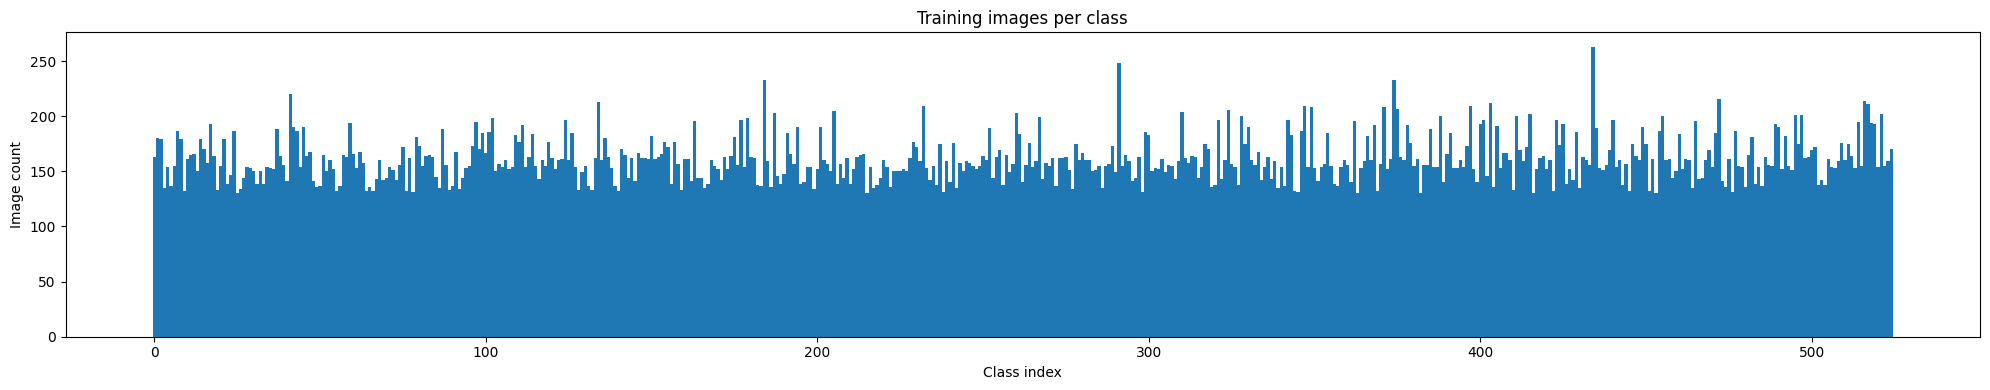

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

train_labels = dataset["train"]["label"]
counts = pd.Series(train_labels).value_counts().sort_index()
counts.index = [label_names[i] for i in counts.index]

print(f"Min images per class: {counts.min()} ({counts.idxmin()})")
print(f"Max images per class: {counts.max()} ({counts.idxmax()})")
print(f"Mean images per class: {counts.mean():.1f}")

plt.figure(figsize=(20, 4))
plt.bar(range(len(counts)), counts.values, width=1.0)
plt.xlabel("Class index")
plt.ylabel("Image count")
plt.title("Training images per class")
plt.tight_layout()
plt.show()

### Why Data Augmentation Matters Here

The training set averages ~161 images per class across 525 classes. While the dataset is well-balanced, 161 images per class is relatively limited for a fine-grained classification task where the model must learn subtle visual differences between species.

Data augmentation artificially expands the effective training set by applying realistic transformations (random crops, horizontal flips, color jitter) to each image at training time. This forces the model to learn features that are invariant to position, orientation, and lighting — reducing overfitting and improving generalization to unseen images.

Without augmentation, the model would likely memorize the training set rather than learn robust bird-specific features.

## 3. Sample Images

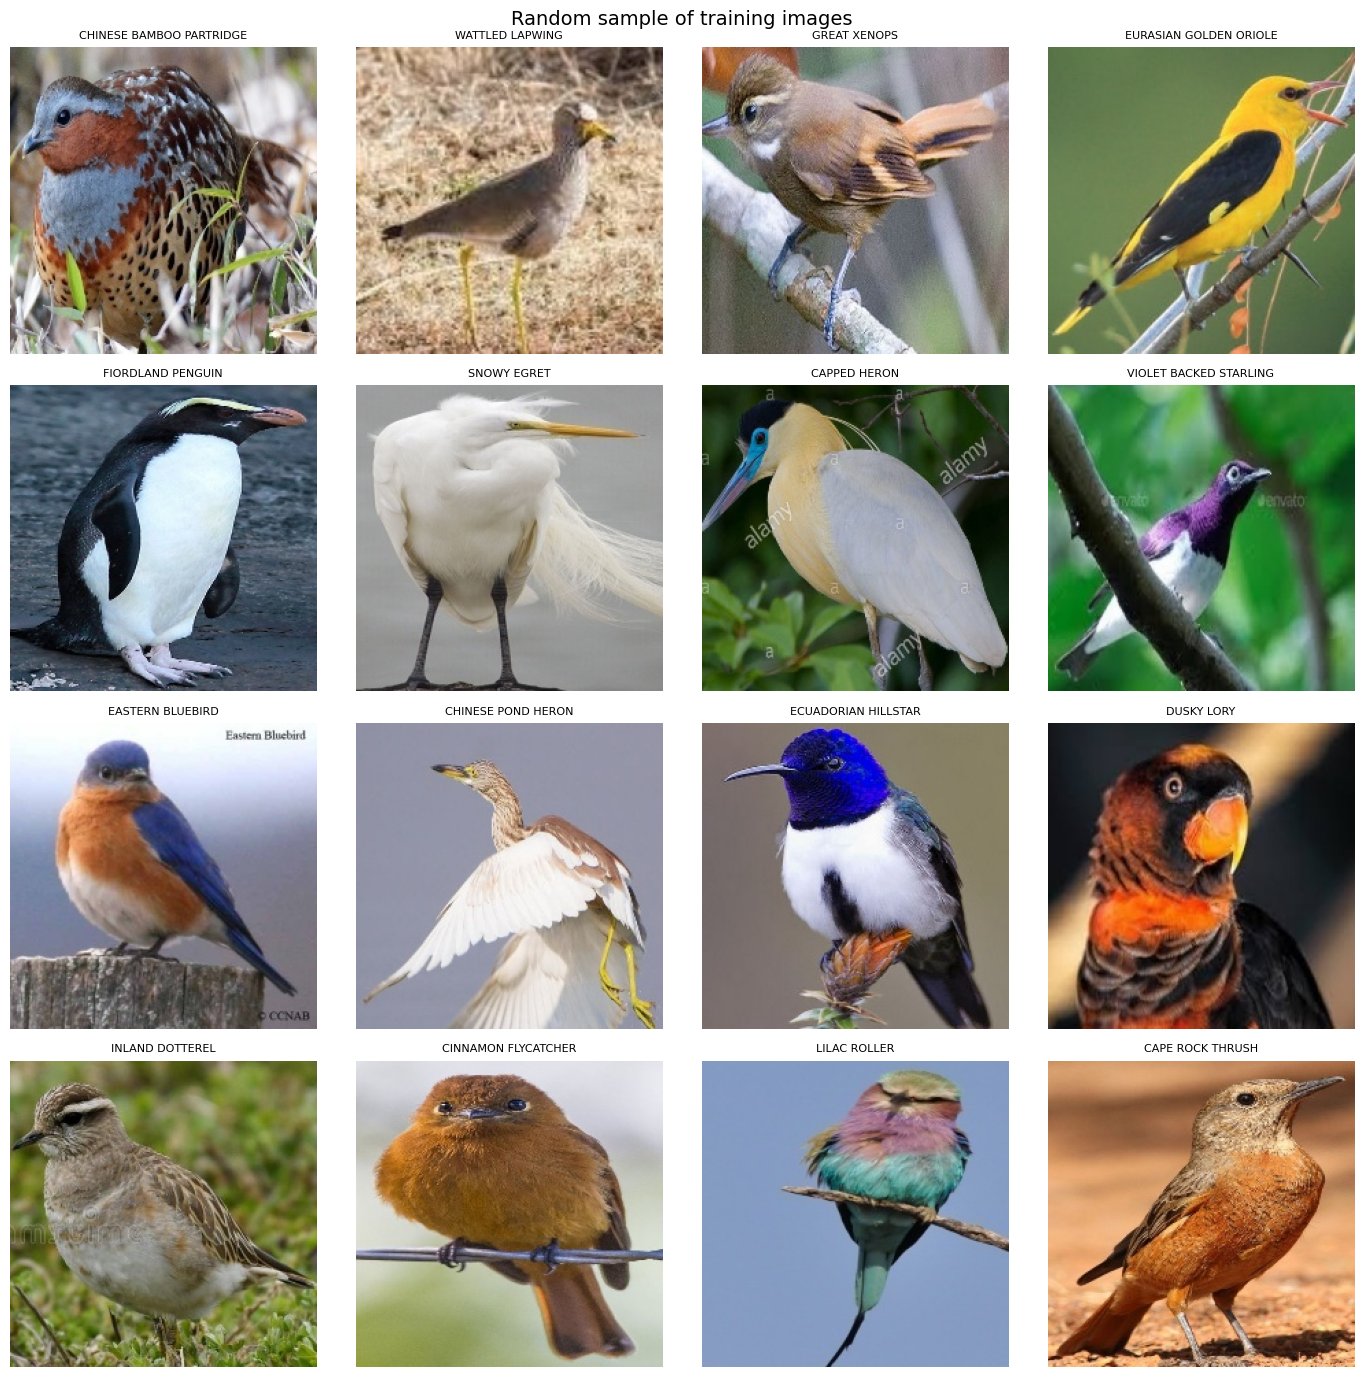

In [5]:
import random
import matplotlib.pyplot as plt

NUM_SAMPLES = 16
indices = random.sample(range(len(dataset["train"])), NUM_SAMPLES)
samples = dataset["train"].select(indices)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for ax, sample in zip(axes.flat, samples):
    ax.imshow(sample["image"])
    ax.set_title(label_names[sample["label"]], fontsize=8)
    ax.axis("off")

plt.suptitle("Random sample of training images", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Image Properties

In [6]:
from collections import Counter

NUM_INSPECT = 500
sample = dataset["train"].select(range(NUM_INSPECT))

modes = Counter()
sizes = Counter()

for item in sample:
    img = item["image"]
    modes[img.mode] += 1
    sizes[img.size] += 1

print("Color modes:")
for mode, count in modes.most_common():
    print(f"  {mode}: {count}/{NUM_INSPECT}")

print(f"\nUnique sizes found: {len(sizes)}")
print("Most common sizes:")
for size, count in sizes.most_common(5):
    print(f"  {size}: {count}")

Color modes:
  RGB: 500/500

Unique sizes found: 1
Most common sizes:
  (224, 224): 500
